# Sources and timing
Explore how the 4 files relate:
1. Do the files contain the same customers?
2. When is the snapshot taken relative to the loan start?
3. Which customers have clickstream data?

## 1. Load files

In [1]:
import pyspark
import pyspark.sql.functions as F
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

spark = pyspark.sql.SparkSession.builder.appName("dev").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

DATA_DIR = "../data"
attributes = spark.read.csv(f"{DATA_DIR}/features_attributes.csv", header=True, inferSchema=True)
financials = spark.read.csv(f"{DATA_DIR}/features_financials.csv", header=True, inferSchema=True)
clickstream = spark.read.csv(f"{DATA_DIR}/feature_clickstream.csv", header=True, inferSchema=True)
lms = spark.read.csv(f"{DATA_DIR}/lms_loan_daily.csv", header=True, inferSchema=True)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/28 04:19:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 2. Do the files contain the same customers?

In [2]:
def customers(df):
    return df.select("Customer_ID").distinct()

for name, df in [("financials", financials), ("clickstream", clickstream), ("lms", lms)]:
    only_in_attributes = customers(attributes).join(customers(df), "Customer_ID", "left_anti").count()
    only_in_other = customers(df).join(customers(attributes), "Customer_ID", "left_anti").count()
    print(f"{name}: {only_in_attributes} customers only in attributes, {only_in_other} only in {name}")

financials: 0 customers only in attributes, 0 only in financials
clickstream: 3526 customers only in attributes, 0 only in clickstream
lms: 0 customers only in attributes, 0 only in lms


**Findings:**
- Attributes, financials and LMS all contain the same 12500 customers
- Every clickstream customer can be found in the 12500; 3526 customers have no clickstream.


## 3. When are attributes and financials taken?

In [3]:
loan_starts = lms.select("Customer_ID", "loan_start_date").distinct()
print("customers with a loan start:", loan_starts.count())

for name, df in [("attributes", attributes), ("financials", financials)]:
    print(name)
    df.select("Customer_ID", "snapshot_date").join(loan_starts, "Customer_ID") \
        .groupBy((col("snapshot_date") == col("loan_start_date")).alias("snapshot_is_loan_start")).count().show()

customers with a loan start: 12500
attributes
+----------------------+-----+
|snapshot_is_loan_start|count|
+----------------------+-----+
|                  true|12500|
+----------------------+-----+

financials
+----------------------+-----+
|snapshot_is_loan_start|count|
+----------------------+-----+
|                  true|12500|
+----------------------+-----+



In [4]:
lms.groupBy(
    (col("snapshot_date") == F.add_months("loan_start_date", col("installment_num"))).alias("matches")
).count().show()

+-------+------+
|matches| count|
+-------+------+
|   true|137500|
+-------+------+



**Findings:**
- `attributes` and `financials` tables: For each customer, `snapshot_date` is the loan start month, so both tables describe the customer at application
- `lms` table: `snapshot_date` is `loan_start_date` plus `installment_num` months, so `installment_num` is the month on book

## 4. Which customers have clickstream data?

In [5]:
has_clickstream = customers(clickstream).withColumn("has_clickstream", F.lit(1))

by_cohort = loan_starts.join(has_clickstream, "Customer_ID", "left").fillna(0, subset=["has_clickstream"]) \
    .groupBy("loan_start_date").agg(F.count("*").alias("customers"), F.sum("has_clickstream").alias("with_clickstream")) \
    .orderBy("loan_start_date").toPandas()

by_cohort

,loan_start_date,customers,with_clickstream
0,2023-01-01,530,530
1,2023-02-01,501,501
2,2023-03-01,506,506
3,2023-04-01,510,510
4,2023-05-01,521,521
5,2023-06-01,517,517
6,2023-07-01,471,471
7,2023-08-01,481,481
8,2023-09-01,454,454
9,2023-10-01,487,487


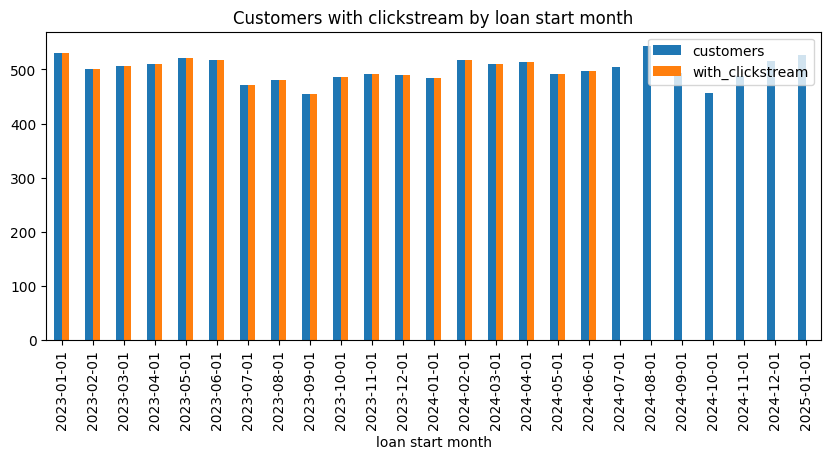

In [6]:
by_cohort.plot(x="loan_start_date", y=["customers", "with_clickstream"], kind="bar", figsize=(10, 4))
plt.title("Customers with clickstream by loan start month")
plt.xlabel("loan start month")
plt.show()

**Findings:**
- Clickstream data available for customers whose loan started from 2023-01 to 2024-06, missing for customer whose loan started from 2024-07 to 2025-01 (later applicants)

## 5. Clickstream months before and after the loan start

In [7]:
timed = clickstream.select("Customer_ID", "snapshot_date").join(loan_starts, "Customer_ID")
timed = timed.withColumn(
    "when",
    F.when(col("snapshot_date") < col("loan_start_date"), "before")
     .when(col("snapshot_date") == col("loan_start_date"), "same month")
     .otherwise("after"))
timed.groupBy("when").count().show()

+----------+------+
|      when| count|
+----------+------+
|     after|130468|
|same month|  8974|
|    before| 75934|
+----------+------+



In [8]:
months_before = timed.groupBy("Customer_ID", "loan_start_date") \
    .agg(F.sum((col("when") == "before").cast("int")).alias("months_before"))

months_before.groupBy("loan_start_date") \
    .agg(F.count("*").alias("customers"), F.min("months_before"), F.max("months_before")).orderBy("loan_start_date").show(20)

+---------------+---------+------------------+------------------+
|loan_start_date|customers|min(months_before)|max(months_before)|
+---------------+---------+------------------+------------------+
|     2023-01-01|      530|                 0|                 0|
|     2023-02-01|      501|                 1|                 1|
|     2023-03-01|      506|                 2|                 2|
|     2023-04-01|      510|                 3|                 3|
|     2023-05-01|      521|                 4|                 4|
|     2023-06-01|      517|                 5|                 5|
|     2023-07-01|      471|                 6|                 6|
|     2023-08-01|      481|                 7|                 7|
|     2023-09-01|      454|                 8|                 8|
|     2023-10-01|      487|                 9|                 9|
|     2023-11-01|      491|                10|                10|
|     2023-12-01|      489|                11|                11|
|     2024

**Findings:**
- 75934 of 215376 clickstream rows are before customer's loan start, 8974 in the same month and 130468 after it
- Months before the loan start range from 0 (loans starting 2023-01) to 17 (loans starting 2024-06)
- Rows after the loan start are future information at the time of application

## 6. Clickstream values

In [9]:
clickstream.select([f"fe_{i}" for i in range(1, 21)]).summary("count", "mean", "stddev", "min", "50%", "max").toPandas().set_index("summary").T

summary,count,mean,stddev,min,50%,max
fe_1,215376,101.41479552039225,99.83359392844184,-378,102,541
fe_2,215376,103.09619456206819,99.93000203749298,-356,103,560
fe_3,215376,104.33370941980536,100.59986549187705,-399,104,583
fe_4,215376,105.64850308298047,100.32606477046183,-307,106,562
fe_5,215376,106.99667558130896,100.69360665858557,-343,107,570
fe_6,215376,103.23592229403462,100.27038751891193,-321,103,565
fe_7,215376,107.0703374563554,100.32326515826574,-368,107,537
fe_8,215376,110.71872446326425,100.24369781781921,-361,111,573
fe_9,215376,114.40635446846446,100.18613852691671,-328,115,577
fe_10,215376,117.77579674615556,100.80768608991778,-317,118,537


In [10]:
clickstream.toPandas().head()

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,63,118,80,121,55,193,111,112,-101,83,...,-16,-81,-126,114,35,85,-73,76,CUS_0x1037,2023-01-01
1,-108,182,123,4,-56,27,25,-6,284,222,...,-14,-96,200,35,130,94,111,75,CUS_0x1069,2023-01-01
2,-13,8,87,166,214,-98,215,152,129,139,...,26,86,171,125,-130,354,17,302,CUS_0x114a,2023-01-01
3,-85,45,200,89,128,54,76,51,61,139,...,172,96,174,163,37,207,180,118,CUS_0x1184,2023-01-01
4,55,120,226,-86,253,97,107,68,103,126,...,76,43,183,159,-26,104,118,184,CUS_0x1297,2023-01-01


**Findings:**
- All 20 features are complete integers with similar distributions (mean about 100 to 118, standard deviation about 100, range roughly -400 to 600)
- No placeholders to clean

## 7. Loans and Lab 2 label

In [11]:
lms.select("tenure", "loan_amt").distinct().show()
lms.groupBy("installment_num").agg(F.min("due_amt"), F.max("due_amt")).orderBy("installment_num").show()

+------+--------+
|tenure|loan_amt|
+------+--------+
|    10|   10000|
+------+--------+

+---------------+------------+------------+
|installment_num|min(due_amt)|max(due_amt)|
+---------------+------------+------------+
|              0|         0.0|         0.0|
|              1|      1000.0|      1000.0|
|              2|      1000.0|      1000.0|
|              3|      1000.0|      1000.0|
|              4|      1000.0|      1000.0|
|              5|      1000.0|      1000.0|
|              6|      1000.0|      1000.0|
|              7|      1000.0|      1000.0|
|              8|      1000.0|      1000.0|
|              9|      1000.0|      1000.0|
|             10|      1000.0|      1000.0|
+---------------+------------+------------+



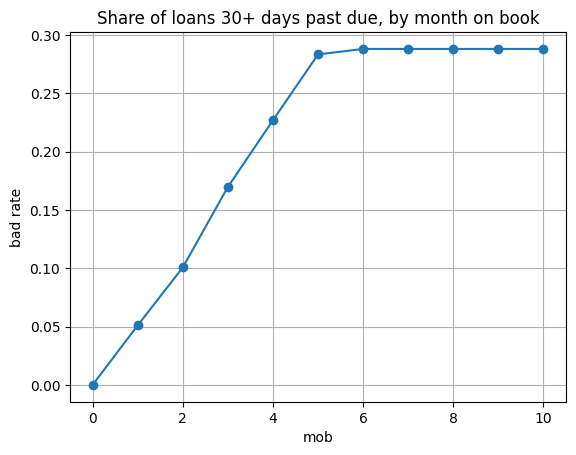

,mob,bad_rate
0,0,0.00000
1,1,0.05104
2,2,0.10072
3,3,0.16968
4,4,0.22696
5,5,0.28344
6,6,0.28816
7,7,0.28816
8,8,0.28816
9,9,0.28816


In [12]:
# Lab 2 silver logic: month on book and days past due
loans = lms.withColumn("mob", col("installment_num"))
loans = loans.withColumn("installments_missed", F.ceil(col("overdue_amt") / col("due_amt")).cast("int")).fillna(0)
loans = loans.withColumn("first_missed_date", F.when(col("installments_missed") > 0, F.add_months(col("snapshot_date"), -1 * col("installments_missed"))))
loans = loans.withColumn("dpd", F.when(col("overdue_amt") > 0.0, F.datediff(col("snapshot_date"), col("first_missed_date"))).otherwise(0))
loans = loans.withColumn("dpd_30", (col("dpd") >= 30).cast("int"))

bad_rate = loans.groupBy("mob").agg(F.avg("dpd_30").alias("bad_rate")).orderBy("mob").toPandas()
bad_rate.plot(x="mob", y="bad_rate", marker="o", grid=True, legend=False)
plt.title("Share of loans 30+ days past due, by month on book")
plt.ylabel("bad rate")
plt.show()
bad_rate

In [13]:
at_mob6 = loans.filter(col("mob") == 6)
print("loans with a mob 6 row: ", at_mob6.count())
at_mob6.groupBy("loan_start_date") \
    .agg(F.count("*").alias("loans"), F.round(F.avg("dpd_30"), 3).alias("bad_rate"), F.min("snapshot_date").alias("label_date")) \
    .orderBy("loan_start_date").show(25)

loans with a mob 6 row: 12500
+---------------+-----+--------+----------+
|loan_start_date|loans|bad_rate|label_date|
+---------------+-----+--------+----------+
|     2023-01-01|  530|   0.264|2023-07-01|
|     2023-02-01|  501|   0.307|2023-08-01|
|     2023-03-01|  506|    0.32|2023-09-01|
|     2023-04-01|  510|   0.269|2023-10-01|
|     2023-05-01|  521|   0.267|2023-11-01|
|     2023-06-01|  517|   0.265|2023-12-01|
|     2023-07-01|  471|   0.297|2024-01-01|
|     2023-08-01|  481|   0.289|2024-02-01|
|     2023-09-01|  454|   0.262|2024-03-01|
|     2023-10-01|  487|   0.257|2024-04-01|
|     2023-11-01|  491|   0.291|2024-05-01|
|     2023-12-01|  489|   0.309|2024-06-01|
|     2024-01-01|  485|   0.297|2024-07-01|
|     2024-02-01|  518|   0.284|2024-08-01|
|     2024-03-01|  511|   0.329|2024-09-01|
|     2024-04-01|  513|   0.277|2024-10-01|
|     2024-05-01|  491|   0.303|2024-11-01|
|     2024-06-01|  498|   0.311|2024-12-01|
|     2024-07-01|  505|   0.307|2025-01-01|
| 

In [15]:
ever_by_mob6 = loans.filter(col("mob") <= 6).groupBy("loan_id").agg(F.max("dpd_30").alias("ever_30dpd"))
print("30+ dpd at mob 6: ", round(at_mob6.agg(F.avg("dpd_30")).first()[0], 3))
print("30+ dpd ever by mob 6: ", round(ever_by_mob6.agg(F.avg("ever_30dpd")).first()[0], 3))

30+ dpd at mob 6:  0.288
30+ dpd ever by mob 6:  0.288


**Findings:**
- Every loan is 10000 over 10 months, with 1000 due from installment 1
- The share of loans 30+ days past due rises to 28.3% at mob 5, reaches 28.8% at mob 6 and stays there, so mob 6 captures almost all eventual defaults
- Every loan has a mob 6 row; the label is observed six months after the loan start (2023-07 for the first cohort, 2025-07 for the last)
- Here "30+ dpd at mob 6" and "30+ dpd ever by mob 6" give the same rate